# 11 — Real global data on the globe

The other globe notebooks build the *base map*; this one drapes **real, whole-world datasets** over the globe with the projected-map API. The data is **WorldClim v2.1** (10-arc-minute, global EPSG:4326 GeoTIFFs, [worldclim.org](https://www.worldclim.org/data/worldclim21.html)):

- **elevation** (`wc2.1_10m_elev`) — a 2160x1080 global DEM, and
- **monthly average temperature** (`wc2.1_10m_tavg`) — 12 global grids.

The data is reprojected to each display CRS by **pyramids**, drawn on a plain axes by **cleopatra**, and framed into a globe by Digital-Earth — `imshow` / `contourf` / `pcolormesh` all work on a projection. Ocean cells are nodata in WorldClim, so the `ocean()` disc shows through the sea automatically.

> The download cell caches into `examples/data/global/` (git-ignored) and is skipped once the files are present. It needs network on first run; everything after is offline.

## Download the data (cached)

Fetch and unzip the two WorldClim products into the local cache.

In [1]:
import io, os, zipfile, urllib.request as u
from pathlib import Path

CACHE = Path('examples/data/global'); CACHE.mkdir(parents=True, exist_ok=True)
BASE = 'https://geodata.ucdavis.edu/climate/worldclim/2_1/base/'

def fetch(product):
    """Download+unzip a WorldClim 10m product, returning the sorted list of cached GeoTIFF paths."""
    tifs = sorted(CACHE.glob(f'{product}*.tif'))
    if tifs:
        return tifs
    blob = u.urlopen(u.Request(BASE + f'{product}.zip', headers={'User-Agent': 'Mozilla/5.0'}),
                     timeout=300).read()
    with zipfile.ZipFile(io.BytesIO(blob)) as z:
        for n in z.namelist():
            if n.endswith('.tif'):
                (CACHE / os.path.basename(n)).write_bytes(z.read(n))
    return sorted(CACHE.glob(f'{product}*.tif'))

ELEV = fetch('wc2.1_10m_elev')[0]
TAVG = fetch('wc2.1_10m_tavg')          # 12 monthly grids, Jan..Dec
print('elevation:', ELEV.name)
print('temperature months:', len(TAVG))

elevation: wc2.1_10m_elev.tif
temperature months: 12


## Read with pyramids

Load the global rasters as `Dataset`s and define a graceful-coastlines helper.

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
from pyramids.dataset import Dataset
from digitalearth.scene import Map, projections

elevation = Dataset.read_file(str(ELEV))
jan = Dataset.read_file(str(TAVG[0]))
jul = Dataset.read_file(str(TAVG[6]))
print('elevation grid:', elevation.rows, 'x', elevation.columns, 'EPSG', elevation.epsg)
print('temperature grid:', jul.rows, 'x', jul.columns, 'EPSG', jul.epsg)

def context(m, *, coast=True):
    """Add coastlines if Natural Earth is reachable; never raise (keeps the notebook running offline)."""
    if not coast:
        return
    try:
        m.coastlines(resolution='110m')
    except Exception as exc:
        print('coastlines unavailable:', type(exc).__name__)

2026-05-31 21:12:15 | INFO | pyramids.base.config | Logging is configured.


elevation grid: 1080 x 2160 EPSG 4326
temperature grid: 1080 x 2160 EPSG 4326


## 1. Global elevation on an orthographic globe

`ocean()` fills the disc, `imshow` draws the reprojected DEM (ocean cells are nodata, so the disc shows through the sea), and `coastlines()` + `graticule()` finish it. `colorbar()` adds the elevation scale.

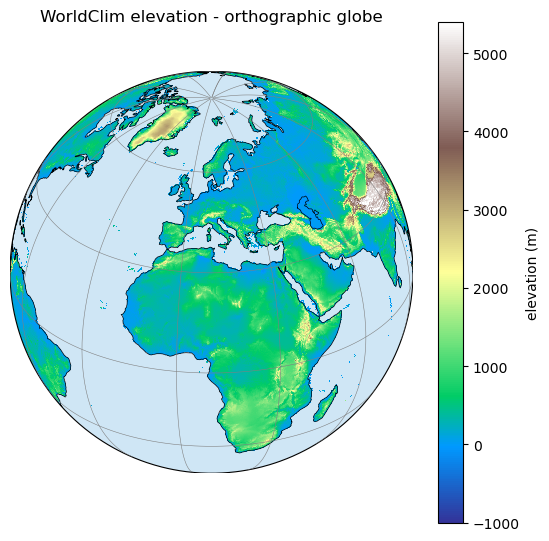

In [3]:
m = Map(crs=projections.orthographic(lon=10, lat=30), globe=True, figsize=(6.5, 6.5))
m.ocean()
m.imshow(elevation, cmap='terrain', vmin=-1000, vmax=5000)
context(m)
m.graticule(lon_step=30, lat_step=30)
m.set_global()
m.colorbar(label='elevation (m)')
m.set_title('WorldClim elevation - orthographic globe')
m.render()
m.fig;

## 2. July temperature — filled contours

`contourf` of the July mean temperature over a globe centred on Asia. The ocean disc shows through where the land grid is nodata.

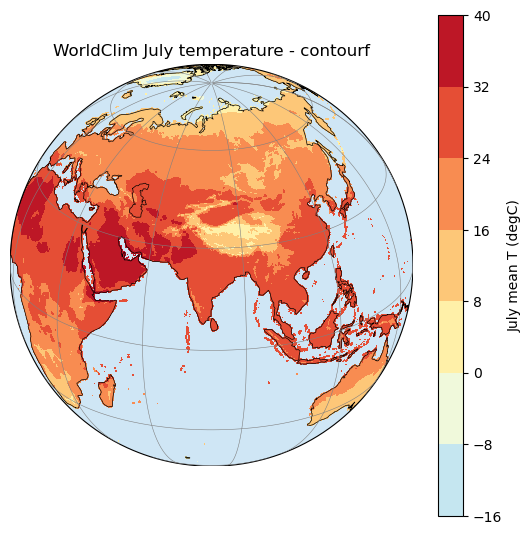

In [4]:
m = Map(crs=projections.orthographic(lon=80, lat=25), globe=True, figsize=(6.5, 6.5))
m.ocean()
m.contourf(jul, cmap='RdYlBu_r', vmin=-40, vmax=40)
context(m)
m.graticule(lon_step=30, lat_step=30)
m.set_global()
m.colorbar(label='July mean T (degC)')
m.set_title('WorldClim July temperature - contourf')
m.render()
m.fig;

## 3. Whole-world projections

The same data on the two equal-ish world projections. **Robinson** with `pcolormesh`, **Mollweide** with `contourf` — both framed and set to the full domain.

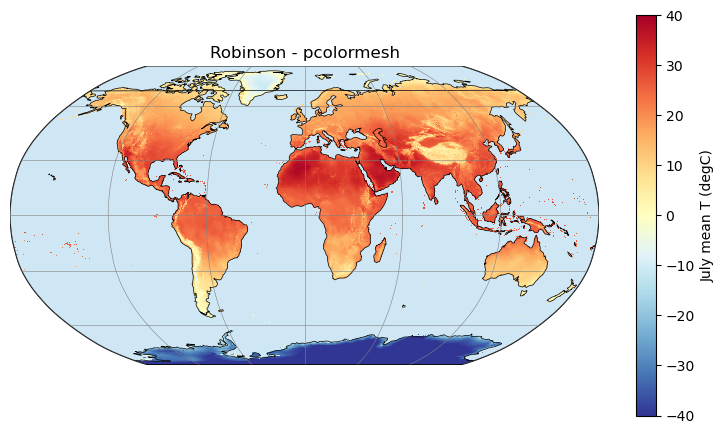

In [5]:
m = Map(crs=projections.robinson(lon=0), globe=True, figsize=(9.5, 5.2))
m.ocean()
m.pcolormesh(jul, cmap='RdYlBu_r', vmin=-40, vmax=40)
context(m)
m.graticule(lon_step=60, lat_step=30)
m.set_global()
m.colorbar(label='July mean T (degC)')
m.set_title('Robinson - pcolormesh')
m.render()
m.fig;

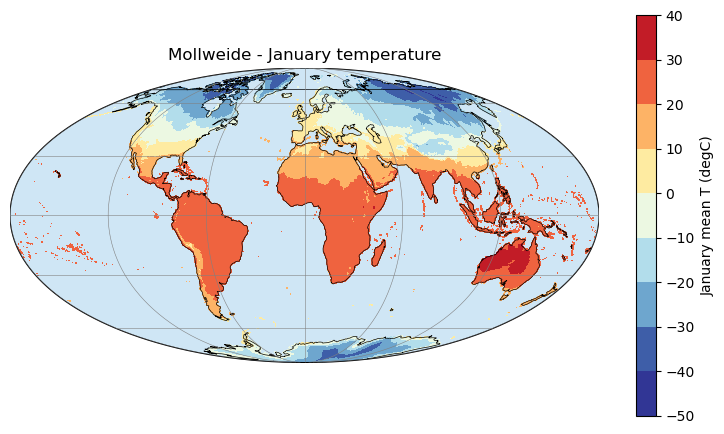

In [6]:
m = Map(crs=projections.mollweide(lon=0), globe=True, figsize=(9.5, 5.2))
m.ocean()
m.contourf(jan, cmap='RdYlBu_r', vmin=-40, vmax=40)
context(m)
m.graticule(lon_step=60, lat_step=30)
m.set_global()
m.colorbar(label='January mean T (degC)')
m.set_title('Mollweide - January temperature')
m.render()
m.fig;

## 4. Seasonal contrast — two globes side by side

`Map` accepts an existing `ax`, so several globes fit in one figure. January vs July temperature on matching orthographic views shows the hemispheres swapping warmth.

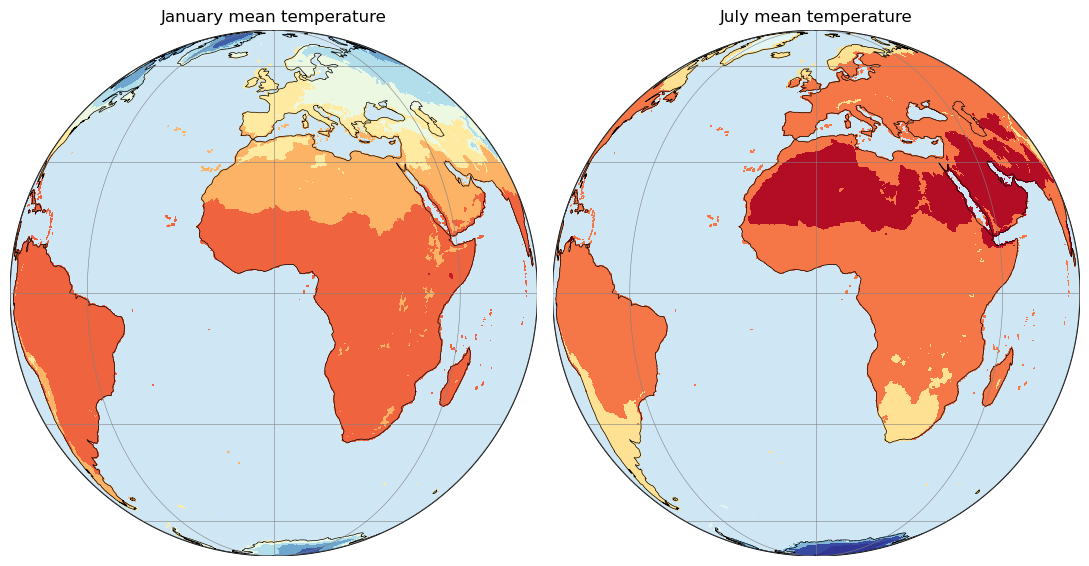

In [7]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(11, 5.6))
for ax, month, label in [(axL, jan, 'January'), (axR, jul, 'July')]:
    m = Map(crs=projections.orthographic(lon=0, lat=0), globe=True, ax=ax)
    m.ocean()
    m.contourf(month, cmap='RdYlBu_r', vmin=-40, vmax=40)
    context(m)
    m.graticule(lon_step=45, lat_step=30)
    m.set_global()
    m.set_title(f'{label} mean temperature')
    m.render()
fig.tight_layout(); fig;

## 5. Save a globe to PNG

`save()` applies the frame and writes the figure; the data and fills are clipped to the boundary in the file.

saved: C:\gdrive\algorithms\Visualization\Digital-Earth\docs\examples\global_elevation_globe.png | 125601 bytes


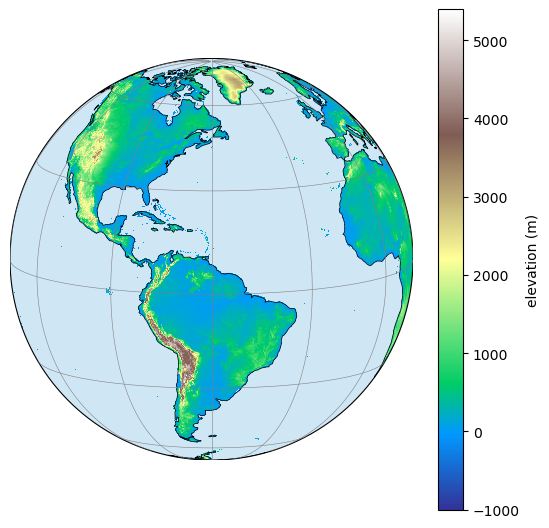

In [8]:
out = Path('global_elevation_globe.png')
m = Map(crs=projections.orthographic(lon=-60, lat=10), globe=True, figsize=(6.5, 6.5))
m.ocean()
m.imshow(elevation, cmap='terrain', vmin=-1000, vmax=5000)
context(m)
m.graticule(); m.set_global()
m.colorbar(label='elevation (m)')
m.save(str(out))
print('saved:', out.resolve(), '|', out.stat().st_size, 'bytes')
out.unlink()  # clean up the example artifact